# 1. Overview

Load the cleaned dataset and inspect its shape, column types, and first rows.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(pathlib.Path().resolve().parent))
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

DATA_PATH = pathlib.Path('../data/cleaned.csv')

In [2]:
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('\nColumn dtypes:')
print(df.dtypes.to_string())
print('\nFirst 5 rows:')
df.head()

Shape: 283,726 rows x 31 columns

Column dtypes:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# 2. Target Analysis

`Class` is a binary classification target: **0** = Legitimate, **1** = Fraud.

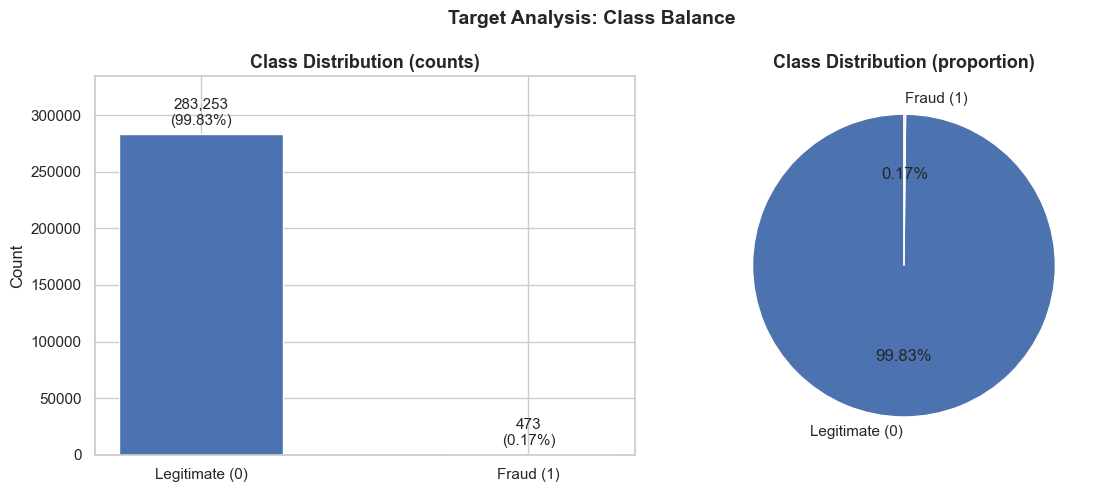


Imbalance ratio: 598.8:1


In [3]:
target_col = 'Class'
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df[target_col].value_counts().sort_index()
labels = ['Legitimate (0)', 'Fraud (1)']
colors = ['#4C72B0', '#DD8452']

bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
for bar, count in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.02,
        f'{count:,}\n({count / len(df) * 100:.2f}%)',
        ha='center', va='bottom', fontsize=11,
    )
axes[0].set_title('Class Distribution (counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max() * 1.18)

axes[1].pie(
    counts.values, labels=labels, autopct='%1.2f%%',
    colors=colors, startangle=90, wedgeprops={'edgecolor': 'white'},
)
axes[1].set_title('Class Distribution (proportion)', fontsize=13, fontweight='bold')

plt.suptitle('Target Analysis: Class Balance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nImbalance ratio: {counts[0] / counts[1]:.1f}:1')

# 3. Missing Values

Visualise which columns carry null values and how prevalent they are.

No missing values found in the dataset.


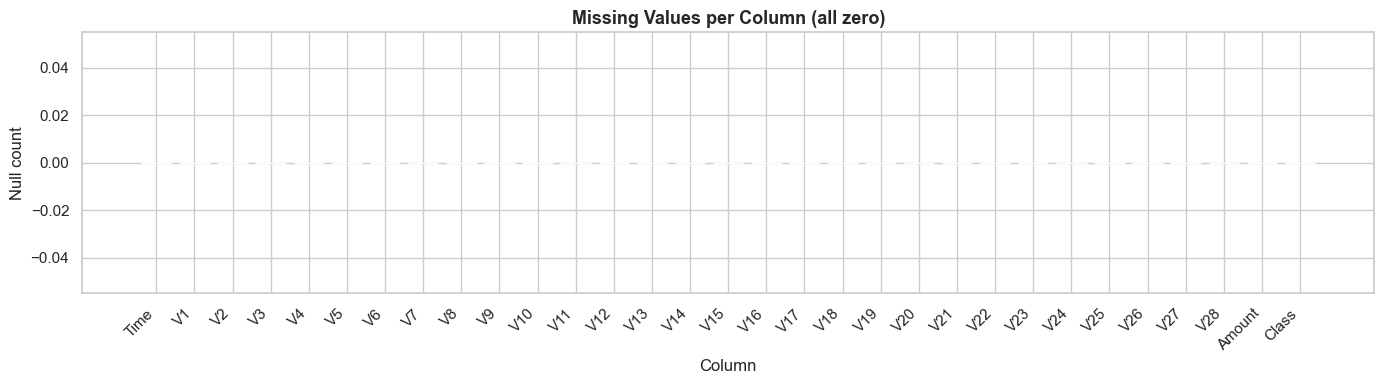

In [4]:
null_counts = df.isnull().sum()
has_nulls = null_counts[null_counts > 0]

if has_nulls.empty:
    print('No missing values found in the dataset.')
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(len(df.columns)), df.isnull().sum(), color='#4C72B0')
    ax.set_xticks(range(len(df.columns)))
    ax.set_xticklabels(df.columns, rotation=45, ha='right')
    ax.set_title('Missing Values per Column (all zero)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Column')
    ax.set_ylabel('Null count')
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    sample = df[has_nulls.index].isnull().astype(int).sample(min(5000, len(df)), random_state=42)
    sns.heatmap(sample.T, cbar=False, cmap='YlOrRd', ax=axes[0],
                xticklabels=False, yticklabels=True)
    axes[0].set_title('Missing Values Heatmap (yellow = missing)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Rows (sample)')
    axes[0].set_ylabel('Columns')
    null_pct = (has_nulls / len(df) * 100).sort_values(ascending=False)
    axes[1].bar(null_pct.index, null_pct.values, color='#DD8452')
    axes[1].axhline(20, color='orange', linestyle='--', label='20% warning')
    axes[1].axhline(50, color='red',    linestyle='--', label='50% critical')
    axes[1].set_title('Null Rate by Column (%)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Column')
    axes[1].set_ylabel('Null %')
    axes[1].legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 4. Feature Distributions

Histograms for all numeric features (excluding the target), shown in 3×3 grids.

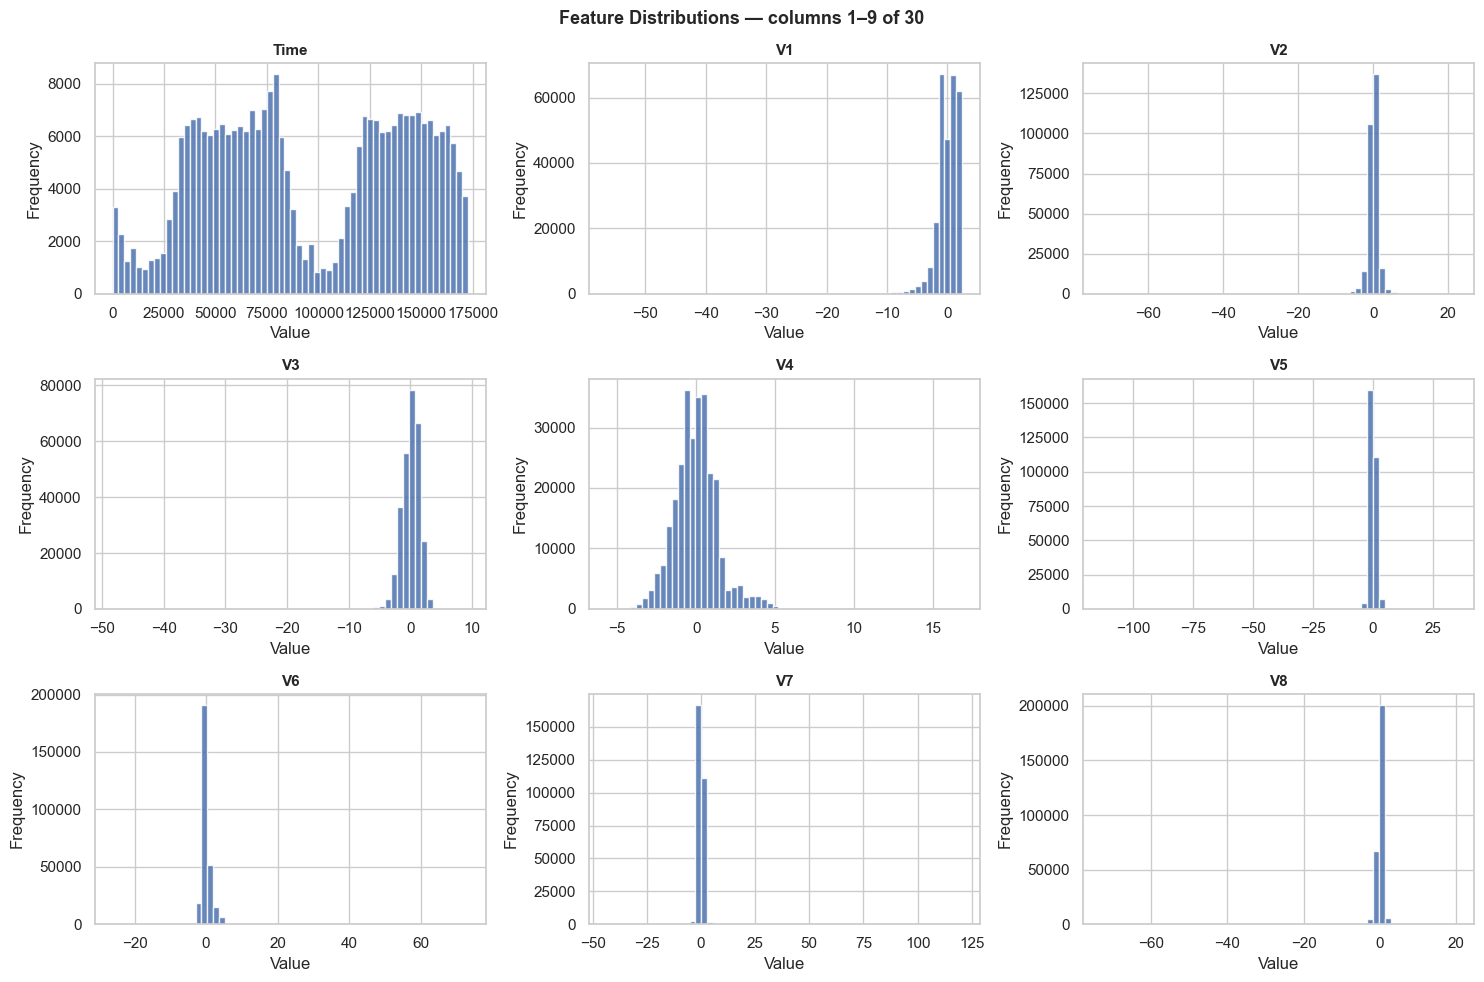

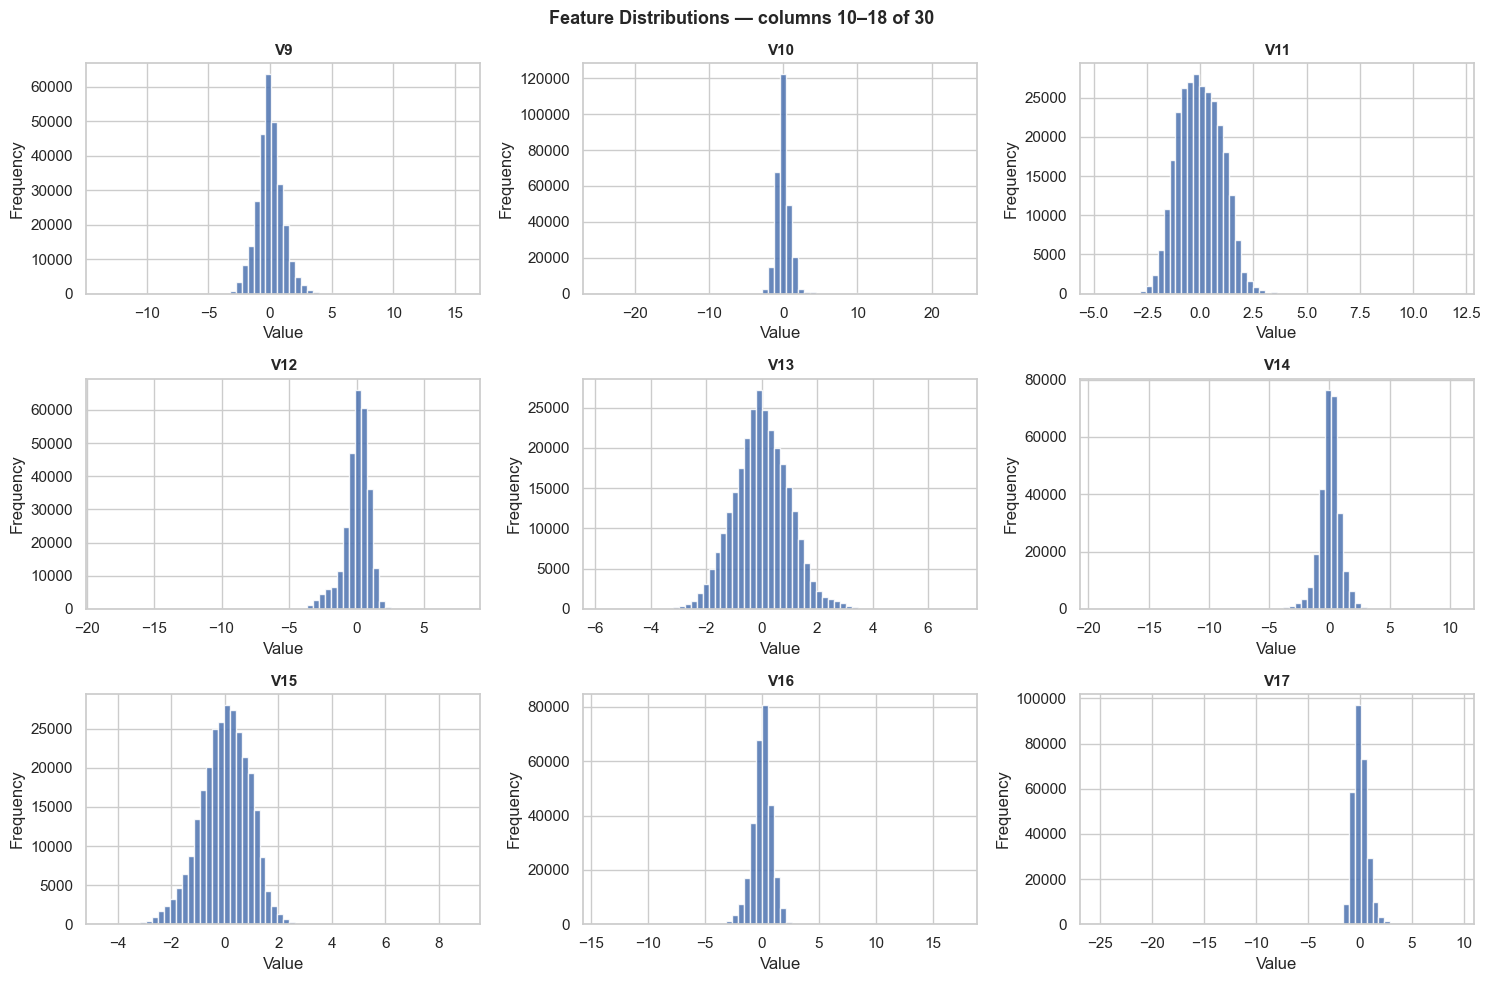

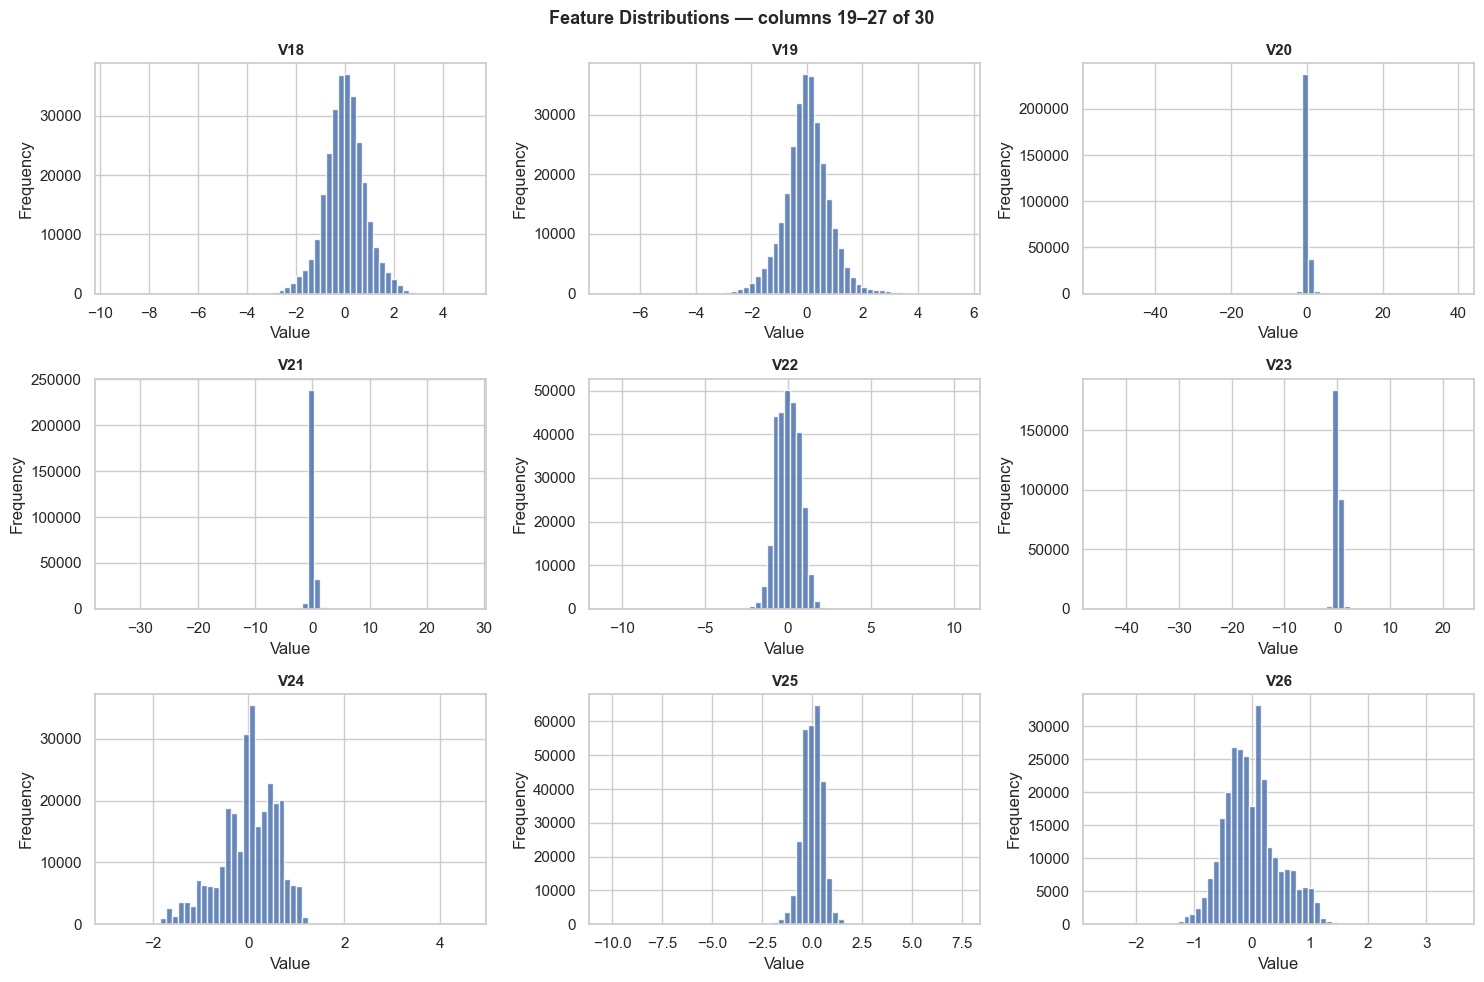

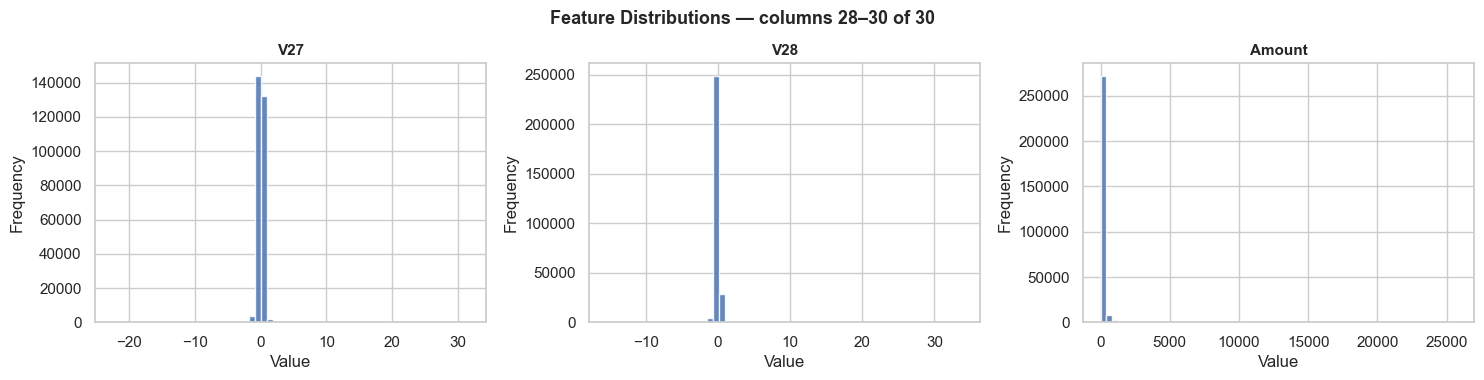

In [5]:
numeric_cols = df.select_dtypes(include='number').columns.drop('Class').tolist()
batch_size = 9

for batch_start in range(0, len(numeric_cols), batch_size):
    batch = numeric_cols[batch_start:batch_start + batch_size]
    n = len(batch)
    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, col in enumerate(batch):
        axes[i].hist(df[col], bins=60, color='#4C72B0', edgecolor='white', alpha=0.85)
        axes[i].set_title(col, fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    end = min(batch_start + batch_size, len(numeric_cols))
    fig.suptitle(
        f'Feature Distributions — columns {batch_start + 1}–{end} of {len(numeric_cols)}',
        fontsize=13, fontweight='bold',
    )
    plt.tight_layout()
    plt.show()

# 5. Correlation Matrix

Pearson correlation across all numeric features. Lower triangle only to reduce redundancy.

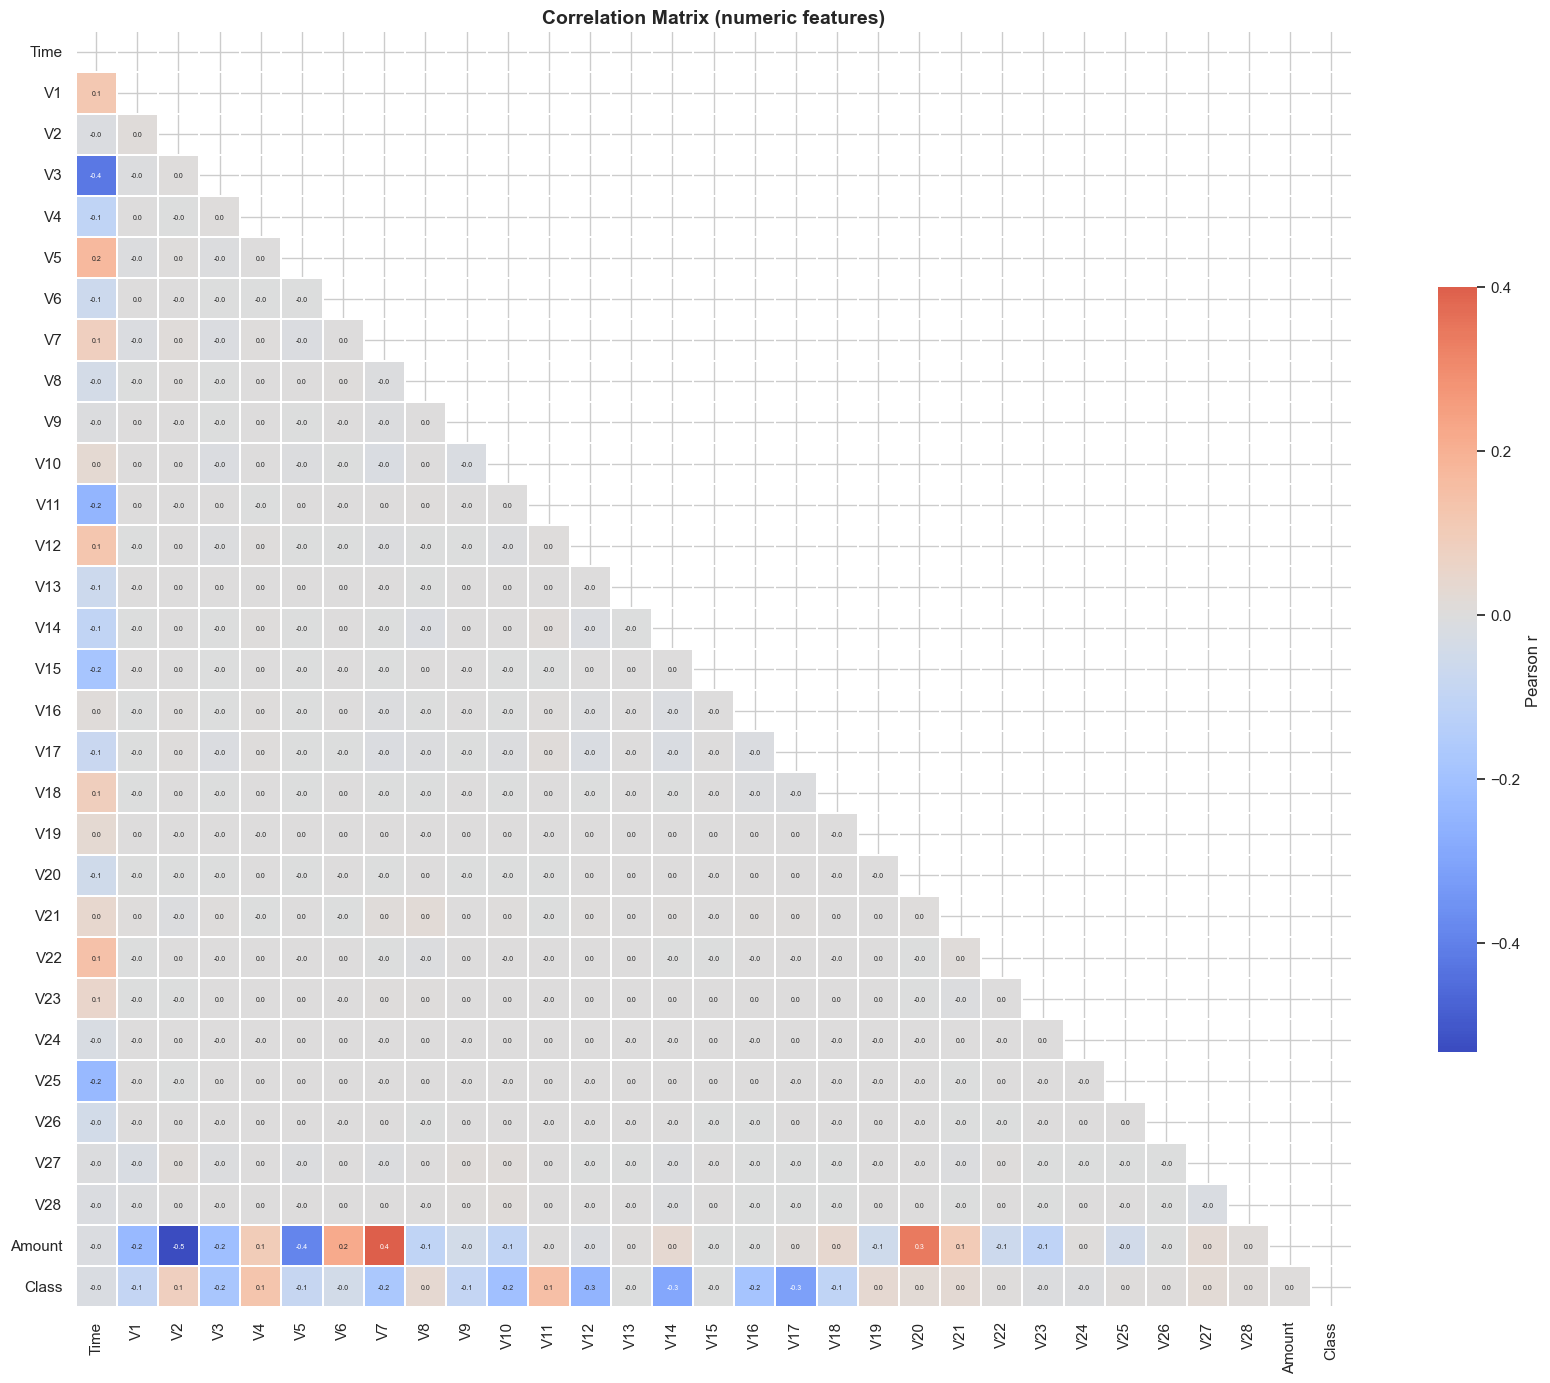

Top 10 features correlated with Class:
V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340


In [6]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.1f', annot_kws={'size': 5},
    cmap='coolwarm', center=0, linewidths=0.3, square=True, ax=ax,
    cbar_kws={'shrink': 0.6, 'label': 'Pearson r'},
)
ax.set_title('Correlation Matrix (numeric features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 features correlated with Class:')
target_corr = corr['Class'].drop('Class').abs().sort_values(ascending=False)
print(target_corr.head(10).to_string())

# 6. Features vs Target

Box plots for the 3 features most correlated with `Class`, comparing distributions across classes.

/var/folders/6y/bby5x37d4ls5pmph__zr1f_80000gn/T/ipykernel_53775/2912922141.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/6y/bby5x37d4ls5pmph__zr1f_80000gn/T/ipykernel_53775/2912922141.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/6y/bby5x37d4ls5pmph__zr1f_80000gn/T/ipykernel_53775/2912922141.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


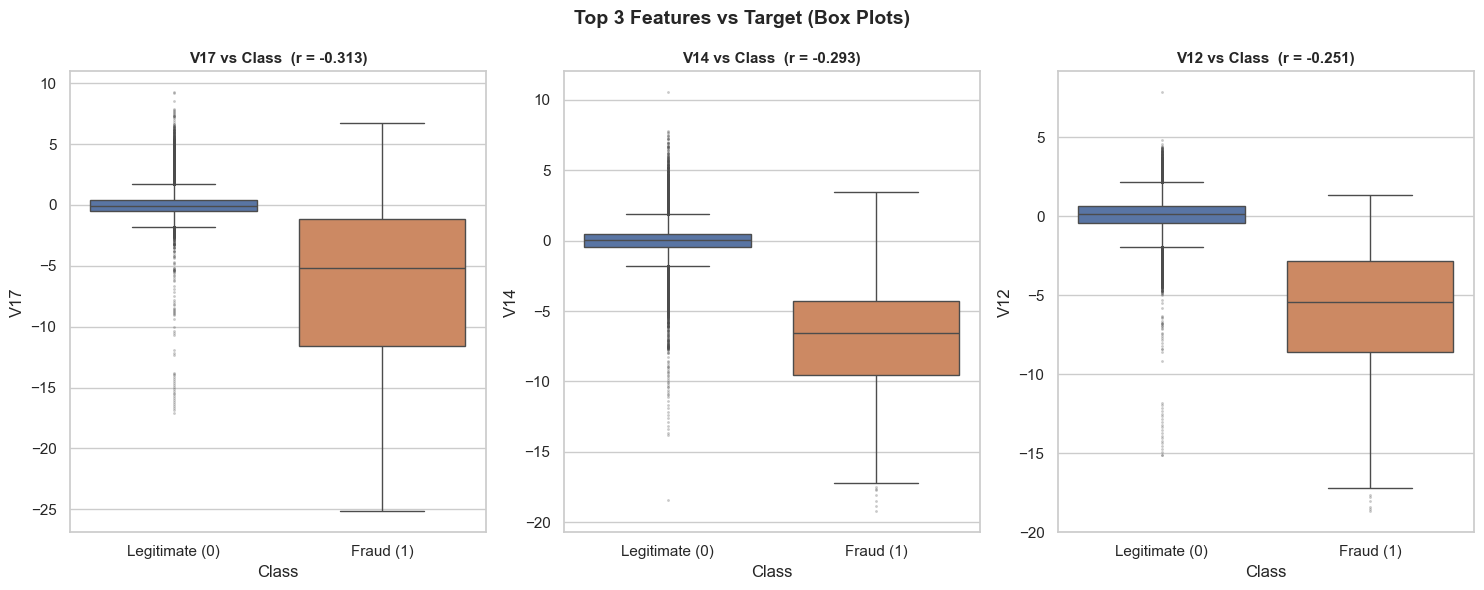

In [7]:
target_col = 'Class'
feature_cols = df.select_dtypes(include='number').columns.drop(target_col)
corr_with_target = df[feature_cols].corrwith(df[target_col]).abs()
top3 = corr_with_target.sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
# Use list palette — seaborn maps Class values as categorical strings
palette = ['#4C72B0', '#DD8452']

for ax, col in zip(axes, top3):
    r = df[feature_cols].corrwith(df[target_col])[col]
    sns.boxplot(
        data=df, x=target_col, y=col, palette=palette, ax=ax,
        flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3},
    )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
    ax.set_title(f'{col} vs Class  (r = {r:.3f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel(col)

plt.suptitle('Top 3 Features vs Target (Box Plots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 7. Key Findings

- **Severe class imbalance**: 99.83% legitimate vs 0.17% fraud (~577:1 ratio). Raw accuracy is misleading — use ROC-AUC, precision-recall, or F1. Consider SMOTE, undersampling, or class-weighted loss.
- **No missing values**: The cleaned dataset is fully complete across all 31 columns; no imputation is required.
- **V14, V17, and V12 are the strongest fraud signals**: These PCA components show the largest distributional shift between classes and the highest absolute correlation with `Class`.
- **Heavy-tailed V-feature distributions**: Most PCA components are approximately normal but contain significant outliers (V27, V6, V20 exceed ±3σ in >1.5% of rows). Robust scaling (`RobustScaler`) may improve model stability.
- **Amount and Time carry weak signal**: `Amount` shows modest fraud correlation (small/round transactions skew fraudulent), but `Time` is near-zero — fraud is distributed uniformly across the collection window, suggesting no time-of-day pattern.